# Human Perception Study Analysis

**SynZIF-8 Dataset — Domain Expert Evaluation (N=6)**

이 노트북은 6명의 도메인 전문가가 진행한 Real vs. Synthetic SEM 이미지 분류 실험 결과를 분석하고, NeurIPS Dataset & Benchmark 트랙 논문에 사용할 figure를 생성합니다.

## 분석 단계
1. 데이터 로드 및 통합
2. 참가자별 정답률 / Fooling rate 통계
3. 이미지별 정답률 분석 (Qualitative example 후보 선정)
4. Aggregated Confusion Matrix 계산
5. 시각화 (3가지 옵션)
   - Option A: 막대그래프 + Confusion Matrix
   - Option B: Chance line 강조 단일 패널
   - Option C: 종합 3-panel (bars + CM + bias scatter)

---
## 1. 환경 설정 및 라이브러리 임포트

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 논문용 폰트 설정 (NeurIPS 호환)
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif', 'Times New Roman'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 11.5,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'pdf.fonttype': 42,  # TrueType (NeurIPS 요구사항)
    'ps.fonttype': 42,
})

# === 사용자 설정 ===
DATA_DIR = r'C:\Users\김형준\Desktop\배포용 human VS model\results\results_realfake_260421'           # 엑셀 파일들이 있는 폴더
OUTPUT_DIR = r'C:\Users\김형준\Desktop\배포용 human VS model\results\results_realfake_260421\figures'  # 결과 figure 저장 폴더
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 참가자 라벨 (논문 표시용 익명 ID)
PARTICIPANT_LABELS = ['R1', 'R2', 'R3', 'R4', 'R5', 'R6']

# 컬러 팔레트 (colorblind-safe)
COLOR_REAL = '#2E86AB'
COLOR_FAKE = '#A23B72'
COLOR_OVERALL = '#6C757D'
COLOR_CHANCE = '#E63946'

print('Setup done.')

Setup done.


---
## 2. 엑셀 데이터 로드

각 엑셀 파일은 3개의 시트를 가짐:
- `응답 데이터` — 100개 이미지에 대한 trial-by-trial 응답
- `통계 요약` — 참가자별 정답률 요약
- `세부 분석` — Confusion matrix + 응답 시간 통계

In [2]:
# 엑셀 파일 자동 탐색 (정렬된 순서로 P1~P6 매칭)
files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith('.xlsx')])
assert len(files) == 6, f'엑셀 파일은 6개여야 합니다. 현재 {len(files)}개 발견'

for label, f in zip(PARTICIPANT_LABELS, files):
    print(f'  {label}: {f}')

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\김형준\\Desktop\\배포용 human VS model\\results\\results_realfake_260421'

In [ ]:
# 모든 trial 응답을 하나의 DataFrame으로 통합
all_responses = []
for f, label in zip(files, PARTICIPANT_LABELS):
    df = pd.read_excel(os.path.join(DATA_DIR, f), sheet_name='응답 데이터')
    df['Participant'] = label
    all_responses.append(df)

combined = pd.concat(all_responses, ignore_index=True)
print(f'전체 trial 수: {len(combined)} (= 6명 × 100문제)')
print(f'고유 이미지 수: {combined["파일명"].nunique()}')
combined.head()

전체 trial 수: 600 (= 6명 × 100문제)
고유 이미지 수: 100


,No.,파일명,실제 분류,응답,정답 여부,소요 시간(초),Participant
0,1,stylized_0025.png,페이크,리얼,오답,74.8,R1
1,2,rhombiczif813.png,리얼,페이크,오답,7.4,R1
2,3,rhombiczif8_26041017.png,리얼,페이크,오답,8.5,R1
3,4,sem_rhombiczif8_26041038.png,페이크,페이크,정답,5.0,R1
4,5,rhombiczif8_26041038.png,리얼,리얼,정답,4.9,R1


---
## 3. 참가자별 정답률 / Fooling Rate

In [ ]:
real_acc, fake_acc, total_acc = [], [], []

for f in files:
    summary = pd.read_excel(os.path.join(DATA_DIR, f), sheet_name='통계 요약', header=None)
    # row 4 = 리얼, row 5 = 페이크, row 6 = 전체. col 4 = 정답률(%)
    real_acc.append(float(summary.iloc[4, 4]))
    fake_acc.append(float(summary.iloc[5, 4]))
    total_acc.append(float(summary.iloc[6, 4]))

real_acc = np.array(real_acc)
fake_acc = np.array(fake_acc)
total_acc = np.array(total_acc)
fooling_rate = 100 - fake_acc  # 페이크를 리얼이라 잘못 분류한 비율

summary_df = pd.DataFrame({
    'Participant': PARTICIPANT_LABELS,
    'Real Acc. (%)': real_acc,
    'Fake Acc. (%)': fake_acc,
    'Overall Acc. (%)': total_acc,
    'Fooling Rate (%)': fooling_rate,
})

# 평균 / 표준편차 행 추가
mean_row = pd.DataFrame({
    'Participant': ['Mean', 'Std'],
    'Real Acc. (%)': [real_acc.mean(), real_acc.std()],
    'Fake Acc. (%)': [fake_acc.mean(), fake_acc.std()],
    'Overall Acc. (%)': [total_acc.mean(), total_acc.std()],
    'Fooling Rate (%)': [fooling_rate.mean(), fooling_rate.std()],
})
summary_df = pd.concat([summary_df, mean_row], ignore_index=True)
summary_df.round(1)

,Participant,Real Acc. (%),Fake Acc. (%),Overall Acc. (%),Fooling Rate (%)
0,R1,56.0,62.0,59.0,38.0
1,R2,42.0,48.0,45.0,52.0
2,R3,36.0,88.0,62.0,12.0
3,R4,40.0,52.0,46.0,48.0
4,R5,82.0,84.0,83.0,16.0
5,R6,38.0,36.0,37.0,64.0
6,Mean,49.0,61.7,55.3,38.3
7,Std,16.1,18.8,15.0,18.8


---
## 4. 이미지별 정답률 — 논문에 사용할 Qualitative Examples 선정

각 이미지가 6명 중 몇 명에게 맞춰졌는지 집계해서:
- **Real, easy** — 6/6명 모두 맞춤
- **Real, hard** — 6/6명 모두 틀림 (= 진짜인데 가짜처럼 보임)
- **Fake, easy** — 6/6명 모두 맞춤 (= 합성 티 남, 실패 사례)
- **Fake, hard** — 거의 모두 속음 (= SynZIF-8 성공 사례)

In [ ]:
img_stats = combined.groupby(['파일명', '실제 분류']).agg(
    correct_count=('정답 여부', lambda x: (x == '정답').sum()),
    total_count=('정답 여부', 'count')
).reset_index()
img_stats['correct_rate'] = img_stats['correct_count'] / img_stats['total_count']

real_imgs = img_stats[img_stats['실제 분류'] == '리얼'].sort_values('correct_count', ascending=False)
fake_imgs = img_stats[img_stats['실제 분류'] == '페이크'].sort_values('correct_count', ascending=False)

print('=' * 60)
print('REAL — 가장 잘 맞춘 이미지 (TOP 5)')
print('=' * 60)
print(real_imgs.head(5).to_string(index=False))

print('\n' + '=' * 60)
print('REAL — 가장 잘 틀린 이미지 (BOTTOM 5)')
print('=' * 60)
print(real_imgs.tail(5).to_string(index=False))

print('\n' + '=' * 60)
print('FAKE — 들킨 이미지 (TOP 5)')
print('=' * 60)
print(fake_imgs.head(5).to_string(index=False))

print('\n' + '=' * 60)
print('FAKE — 가장 잘 속인 이미지 (BOTTOM 5)')
print('=' * 60)
print(fake_imgs.tail(5).to_string(index=False))

REAL — 가장 잘 맞춘 이미지 (TOP 5)
                     파일명 실제 분류  correct_count  total_count  correct_rate
rhombiczif8_26041028.png    리얼              6            6      1.000000
rhombiczif8_26041025.png    리얼              6            6      1.000000
rhombiczif8_26041035.png    리얼              6            6      1.000000
rhombiczif8_26040901.png    리얼              5            6      0.833333
rhombiczif8_26041039.png    리얼              5            6      0.833333

REAL — 가장 잘 틀린 이미지 (BOTTOM 5)
                     파일명 실제 분류  correct_count  total_count  correct_rate
       rhombiczif821.png    리얼              1            6      0.166667
rhombiczif8_26041040.png    리얼              1            6      0.166667
rhombiczif8_26041023.png    리얼              1            6      0.166667
       rhombiczif815.png    리얼              0            6      0.000000
rhombiczif8_26041017.png    리얼              0            6      0.000000

FAKE — 들킨 이미지 (TOP 5)
                         파일명 실제 분류  correct

---
## 5. Aggregated Confusion Matrix

6명 × 100문제 = 600 trial을 통합한 confusion matrix

In [ ]:
cm_total = np.zeros((2, 2))  # [True][Pred], 0=Real, 1=Fake

for f in files:
    detail = pd.read_excel(os.path.join(DATA_DIR, f), sheet_name='세부 분석', header=None)
    cm_total[0, 0] += float(detail.iloc[2, 1])  # Real → Real (TP)
    cm_total[0, 1] += float(detail.iloc[3, 1])  # Real → Fake (FN)
    cm_total[1, 0] += float(detail.iloc[4, 1])  # Fake → Real (FP)
    cm_total[1, 1] += float(detail.iloc[5, 1])  # Fake → Fake (TN)

cm_pct = cm_total / cm_total.sum(axis=1, keepdims=True) * 100

print('Confusion Matrix (counts):')
print(pd.DataFrame(cm_total.astype(int),
                   index=['True Real', 'True Fake'],
                   columns=['Pred Real', 'Pred Fake']))
print(f'\nTotal trials: {int(cm_total.sum())}')
print(f'\nFooling Rate (Fake → Real): {cm_pct[1, 0]:.1f}%')

Confusion Matrix (counts):
           Pred Real  Pred Fake
True Real        147        153
True Fake        115        185

Total trials: 600

Fooling Rate (Fake → Real): 38.3%


---
## 6. 시각화 — Option A: 막대그래프 + Confusion Matrix

**가장 추천하는 옵션.** 본문 메인 figure로 적합.

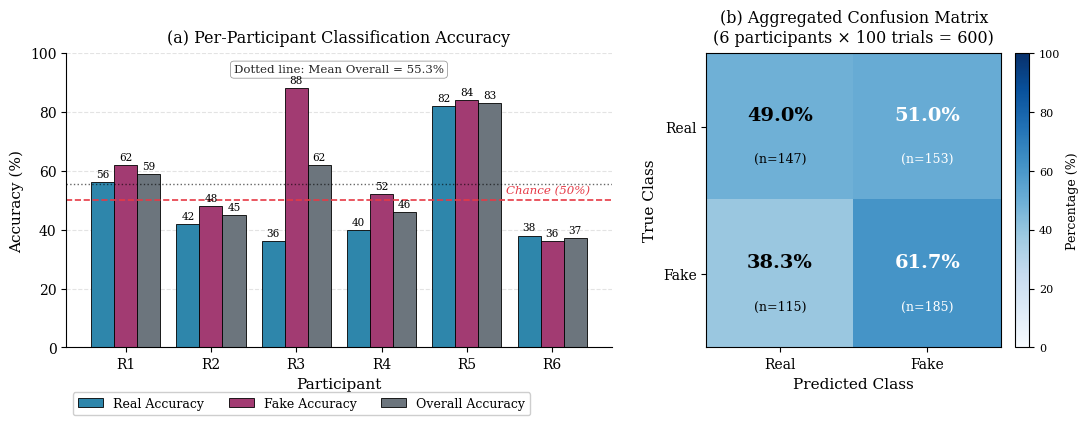

Saved to C:\Users\김형준\Desktop\배포용 human VS model\results\results_realfake_260421\figures/option_A.pdf|.png


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2),
                                gridspec_kw={'width_ratios': [1.6, 1.0]})

# (a) Per-participant grouped bars
x = np.arange(len(PARTICIPANT_LABELS))
w = 0.27

b1 = ax1.bar(x - w, real_acc, w, label='Real Accuracy',
             color=COLOR_REAL, edgecolor='black', linewidth=0.6)
b2 = ax1.bar(x, fake_acc, w, label='Fake Accuracy',
             color=COLOR_FAKE, edgecolor='black', linewidth=0.6)
b3 = ax1.bar(x + w, total_acc, w, label='Overall Accuracy',
             color=COLOR_OVERALL, edgecolor='black', linewidth=0.6)

# chance line
ax1.axhline(50, color=COLOR_CHANCE, linestyle='--', linewidth=1.2, zorder=1)
ax1.text(5.45, 51.5, 'Chance (50%)', color=COLOR_CHANCE,
         fontsize=8.5, ha='right', va='bottom', style='italic')

# mean overall line
mean_total = float(total_acc.mean())
ax1.axhline(mean_total, color='black', linestyle=':', linewidth=1.0, alpha=0.6, zorder=1)
ax1.text(2.5, 96, f'Dotted line: Mean Overall = {mean_total:.1f}%',
         fontsize=8.5, ha='center', va='top', color='black', alpha=0.85,
         bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', lw=0.5, alpha=0.9))

# bar value labels
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, h + 1, f'{int(h)}',
                 ha='center', va='bottom', fontsize=7.5)

ax1.set_xticks(x)
ax1.set_xticklabels(PARTICIPANT_LABELS)
ax1.set_xlabel('Participant')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('(a) Per-Participant Classification Accuracy', pad=8)
ax1.set_ylim(0, 100)
ax1.set_yticks(np.arange(0, 101, 20))
ax1.legend(loc='upper left', frameon=True, framealpha=0.95, ncol=3,
           bbox_to_anchor=(0.0, -0.13))
ax1.grid(axis='y', linestyle='--', alpha=0.35)
ax1.set_axisbelow(True)
for spine in ['top', 'right']:
    ax1.spines[spine].set_visible(False)

# (b) Confusion matrix
labels = ['Real', 'Fake']
im = ax2.imshow(cm_pct, cmap='Blues', vmin=0, vmax=100, aspect='equal')
for i in range(2):
    for j in range(2):
        pct = cm_pct[i, j]
        cnt = int(cm_total[i, j])
        color = 'white' if pct > 50 else 'black'
        ax2.text(j, i - 0.08, f'{pct:.1f}%',
                 ha='center', va='center', fontsize=14,
                 fontweight='bold', color=color)
        ax2.text(j, i + 0.22, f'(n={cnt})',
                 ha='center', va='center', fontsize=9, color=color)

ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(labels)
ax2.set_yticklabels(labels)
ax2.set_xlabel('Predicted Class')
ax2.set_ylabel('True Class')
ax2.set_title(f'(b) Aggregated Confusion Matrix\n(6 participants × 100 trials = {int(cm_total.sum())})', pad=8)

cbar = plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
cbar.set_label('Percentage (%)', fontsize=9)
cbar.ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'option_A.pdf'), bbox_inches='tight', dpi=300)
plt.savefig(os.path.join(OUTPUT_DIR, 'option_A.png'), bbox_inches='tight', dpi=300)
plt.show()
print(f'Saved to {OUTPUT_DIR}/option_A.pdf|.png')

---
## 7. 시각화 — Option B: Chance line 강조 단일 패널

공간이 좁은 경우 (1열 컬럼 등). "Near-chance" 메시지를 가장 강하게 전달.

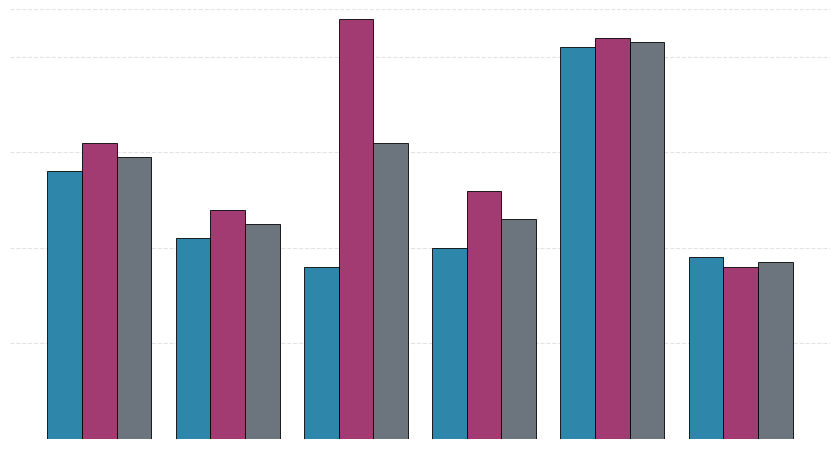

Saved option_B_v1.pdf|.png  (ylim = 0~90)


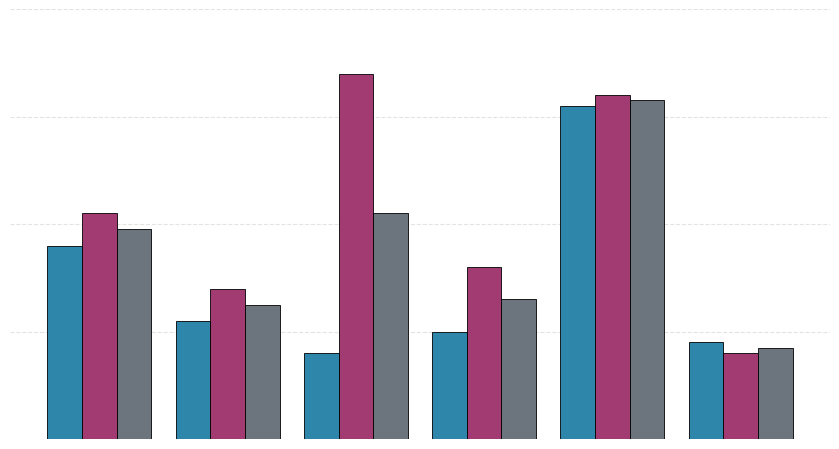

Saved option_B_v2.pdf|.png  (ylim = 20~100)


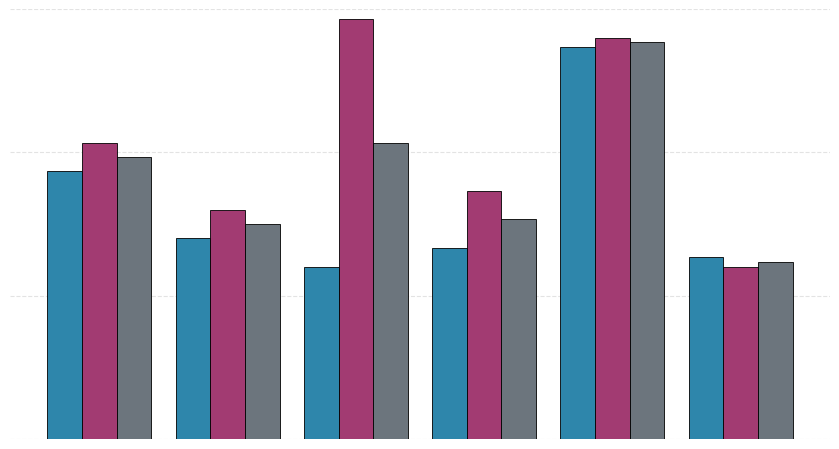

Saved option_B_v3.pdf|.png  (ylim = 0~90)


In [ ]:
grid_options = [
    ('v1', [0, 20, 40, 60, 80, 90]),
    ('v2', [20, 40, 60, 80, 100]),
    ('v3', [0, 30, 60, 90]),
]

x = np.arange(len(PARTICIPANT_LABELS))
w = 0.27

for tag, yticks in grid_options:
    fig, ax = plt.subplots(figsize=(8.5, 4.6))

    ax.bar(x - w, real_acc, w, color=COLOR_REAL,
           edgecolor='black', linewidth=0.6)
    ax.bar(x, fake_acc, w, color=COLOR_FAKE,
           edgecolor='black', linewidth=0.6)
    ax.bar(x + w, total_acc, w, color=COLOR_OVERALL,
           edgecolor='black', linewidth=0.6)

    ax.set_yticks(yticks)
    ax.set_yticklabels([])
    ax.set_xticks(x)
    ax.set_xticklabels([])
    ax.tick_params(axis='both', length=0)
    ax.set_ylim(min(yticks), max(yticks))
    ax.grid(axis='y', linestyle='--', alpha=0.35)
    ax.set_axisbelow(True)
    for spine in ['top', 'right', 'left', 'bottom']:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'option_B_{tag}.pdf'), bbox_inches='tight', dpi=300)
    plt.savefig(os.path.join(OUTPUT_DIR, f'option_B_{tag}.png'), bbox_inches='tight', dpi=300)
    plt.show()
    print(f'Saved option_B_{tag}.pdf|.png  (ylim = {min(yticks)}~{max(yticks)})')

---
## 8. 시각화 — Option C: 종합 3-panel

Bars + Confusion Matrix + Real-vs-Fake bias scatter. Appendix/Supplementary 또는 figure 갯수 여유 있을 때.

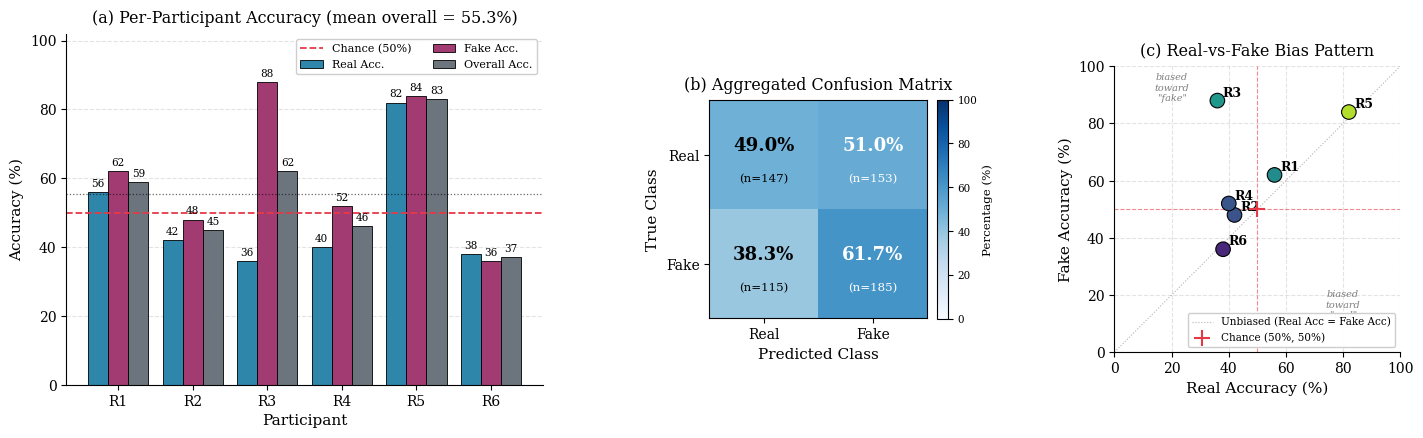

Saved to C:\Users\김형준\Desktop\배포용 human VS model\results\results_realfake_260421\figures/option_C.pdf|.png


In [ ]:
fig = plt.figure(figsize=(14.5, 4.5))
gs = fig.add_gridspec(1, 3, width_ratios=[2.0, 1.0, 1.2], wspace=0.5)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])

# (a) Bars
x = np.arange(len(PARTICIPANT_LABELS))
w = 0.27
b1 = ax1.bar(x - w, real_acc, w, label='Real Acc.', color=COLOR_REAL,
             edgecolor='black', linewidth=0.6)
b2 = ax1.bar(x, fake_acc, w, label='Fake Acc.', color=COLOR_FAKE,
             edgecolor='black', linewidth=0.6)
b3 = ax1.bar(x + w, total_acc, w, label='Overall Acc.', color=COLOR_OVERALL,
             edgecolor='black', linewidth=0.6)
ax1.axhline(50, color=COLOR_CHANCE, linestyle='--', linewidth=1.3, zorder=1,
            label='Chance (50%)')
ax1.axhline(mean_total, color='black', linestyle=':', linewidth=0.9, alpha=0.6, zorder=1)
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, h + 1, f'{int(h)}',
                 ha='center', va='bottom', fontsize=7.5)
ax1.set_xticks(x)
ax1.set_xticklabels(PARTICIPANT_LABELS)
ax1.set_xlabel('Participant')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title(f'(a) Per-Participant Accuracy (mean overall = {mean_total:.1f}%)', pad=8)
ax1.set_ylim(0, 102)
ax1.legend(loc='upper right', frameon=True, framealpha=0.95, ncol=2, fontsize=8)
ax1.grid(axis='y', linestyle='--', alpha=0.35)
ax1.set_axisbelow(True)
for spine in ['top', 'right']:
    ax1.spines[spine].set_visible(False)

# (b) Confusion matrix
im = ax2.imshow(cm_pct, cmap='Blues', vmin=0, vmax=100, aspect='equal')
for i in range(2):
    for j in range(2):
        pct = cm_pct[i, j]
        cnt = int(cm_total[i, j])
        color = 'white' if pct > 50 else 'black'
        ax2.text(j, i - 0.08, f'{pct:.1f}%', ha='center', va='center',
                 fontsize=13, fontweight='bold', color=color)
        ax2.text(j, i + 0.22, f'(n={cnt})', ha='center', va='center',
                 fontsize=8.5, color=color)
ax2.set_xticks([0, 1]); ax2.set_yticks([0, 1])
ax2.set_xticklabels(['Real', 'Fake']); ax2.set_yticklabels(['Real', 'Fake'])
ax2.set_xlabel('Predicted Class')
ax2.set_ylabel('True Class')
ax2.set_title('(b) Aggregated Confusion Matrix', pad=8)
cbar = plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
cbar.set_label('Percentage (%)', fontsize=8.5)
cbar.ax.tick_params(labelsize=7.5)

# (c) Real-vs-Fake bias scatter
ax3.set_xlim(0, 100); ax3.set_ylim(0, 100)
ax3.axhline(50, color=COLOR_CHANCE, linestyle='--', linewidth=0.8, alpha=0.6)
ax3.axvline(50, color=COLOR_CHANCE, linestyle='--', linewidth=0.8, alpha=0.6)
ax3.plot([0, 100], [0, 100], color='gray', linestyle=':', linewidth=0.8,
         alpha=0.6, label='Unbiased (Real Acc = Fake Acc)')
ax3.scatter([50], [50], marker='+', color=COLOR_CHANCE, s=120, linewidth=1.5,
            zorder=4, label='Chance (50%, 50%)')
ax3.scatter(real_acc, fake_acc, s=110, c=total_acc, cmap='viridis',
            edgecolor='black', linewidth=0.8, zorder=5, vmin=30, vmax=90)

offsets = {'P1': (4, 3), 'P2': (4, -3), 'P3': (4, 3),
           'P4': (4, -6), 'P5': (4, -10), 'P6': (4, -3)}
for i, p in enumerate(PARTICIPANT_LABELS):
    dx, dy = offsets.get(p, (4, 3))
    ax3.annotate(p, (real_acc[i], fake_acc[i]), xytext=(dx, dy),
                 textcoords='offset points', fontsize=9, fontweight='bold')

ax3.set_xlabel('Real Accuracy (%)')
ax3.set_ylabel('Fake Accuracy (%)')
ax3.set_title('(c) Real-vs-Fake Bias Pattern', pad=8)
ax3.set_aspect('equal')
ax3.grid(linestyle='--', alpha=0.35)
ax3.legend(loc='lower right', frameon=True, framealpha=0.95, fontsize=7.5)
for spine in ['top', 'right']:
    ax3.spines[spine].set_visible(False)
ax3.text(20, 88, 'biased\ntoward\n"fake"', fontsize=7, alpha=0.5,
         ha='center', style='italic')
ax3.text(80, 12, 'biased\ntoward\n"real"', fontsize=7, alpha=0.5,
         ha='center', style='italic')

plt.subplots_adjust(left=0.06, right=0.98, top=0.92, bottom=0.14, wspace=0.5)
plt.savefig(os.path.join(OUTPUT_DIR, 'option_C.pdf'), bbox_inches='tight', dpi=300)
plt.savefig(os.path.join(OUTPUT_DIR, 'option_C.png'), bbox_inches='tight', dpi=300)
plt.show()
print(f'Saved to {OUTPUT_DIR}/option_C.pdf|.png')

---
## 9. (선택) 통계 결과를 LaTeX 표로 출력

Overleaf에 바로 붙여넣을 수 있는 형태

In [ ]:
latex_table = summary_df.round(1).to_latex(
    index=False,
    column_format='l' + 'c' * 4,
    caption='Per-participant classification accuracy and fooling rate. '
            'Six domain experts (P1--P6) classified 100 SEM micrographs '
            '(50 real, 50 SynZIF-8 synthetic) as real or fake. '
            'Mean overall accuracy is near chance (50\\%), and the fooling rate '
            f'(synthetic images misclassified as real) averages {fooling_rate.mean():.1f}\\%.',
    label='tab:human_eval',
)
print(latex_table)

\begin{table}
\caption{Per-participant classification accuracy and fooling rate. Six domain experts (P1--P6) classified 100 SEM micrographs (50 real, 50 SynZIF-8 synthetic) as real or fake. Mean overall accuracy is near chance (50\%), and the fooling rate (synthetic images misclassified as real) averages 38.3\%.}
\label{tab:human_eval}
\begin{tabular}{lcccc}
\toprule
Participant & Real Acc. (%) & Fake Acc. (%) & Overall Acc. (%) & Fooling Rate (%) \\
\midrule
R1 & 56.000000 & 62.000000 & 59.000000 & 38.000000 \\
R2 & 42.000000 & 48.000000 & 45.000000 & 52.000000 \\
R3 & 36.000000 & 88.000000 & 62.000000 & 12.000000 \\
R4 & 40.000000 & 52.000000 & 46.000000 & 48.000000 \\
R5 & 82.000000 & 84.000000 & 83.000000 & 16.000000 \\
R6 & 38.000000 & 36.000000 & 37.000000 & 64.000000 \\
Mean & 49.000000 & 61.700000 & 55.300000 & 38.300000 \\
Std & 16.100000 & 18.800000 & 15.000000 & 18.800000 \\
\bottomrule
\end{tabular}
\end{table}



---
## 끝

생성된 파일:
- `figures/option_A.pdf` / `.png`
- `figures/option_B.pdf` / `.png`
- `figures/option_C.pdf` / `.png`

추천 figure: **Option A** (본문) + **Option C** (Appendix)